In [2]:
import numpy as np
import math
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

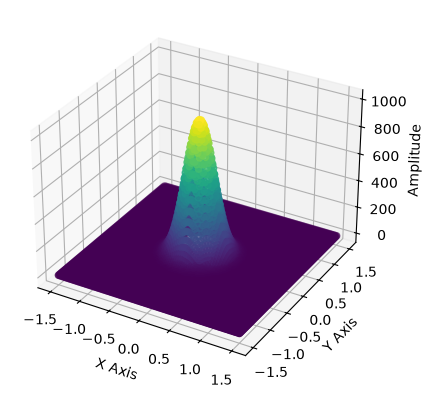

In [3]:
# defining all the functions

def wavenumber(n, wavelength):
    """
    Outputs the angular wavenumber for propagation of a wave
    Args:
        n (float): index of refraction of the medium
        wavelength (float): the wavelength of the wave in nanometres
    Returns:
        k (float): the wavenumber
    """
    wavelength = wavelength * (10**-9) # converts to metres
    k = (2 * math.pi * n)/wavelength # calculates k
    return k

def rho(x, y):
    """
    Finds rho for a gaussian beam
    Args:
        x (float): x coordinate
        y (float): y coordinate
    Returns:
        rho (float): the value of rho at (x,y)
    """
    rho = np.sqrt((x**2)+(y**2))
    return rho

def rayleigh_range(omega_0, wavelength):
    """
    Finds the rayleigh range for a given beam waist radius
    Args:
        omega_0 (float): the waist radius
        wavelength (float): wavelength of the beam in nm
    Returns:
        confocal_parameter (float): the rayleigh range z_0
    """
    wavelength = wavelength * (10**-9) # converts wavelength to metres
    confocal_parameter = (np.pi * (omega_0**2))/wavelength
    return confocal_parameter

def omega_z(omega_0, z, wavelength):
    """
    Calculates omega(z)
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        beam_width (float): omega(z) for given args
    """
    square_of_ratio = (z/rayleigh_range(omega_0, wavelength))**2 # finds (z/z_0)^2
    beam_width = omega_0 * np.sqrt(1+square_of_ratio) # w(z) = w_0*(1+(z/z_0)^2)^0.5
    return beam_width

def radius_of_curvature(omega_0, z, wavelength):
    """
    Calculates the radius of curvature of the wavefront
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        R_z (float): the radius of curvature of the wavefront at z
    """
    square_of_ratio = (rayleigh_range(omega_0, wavelength)/z)**2 # (z_0/z)^2
    R_z = z * (1 + square_of_ratio)
    return R_z

def zeta_function(omega_0, z, wavelength):
    """
    Performs the relevant zeta function to gaussian beams
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        zeta_z (float): the relevant zeta function
    """
    zeta_z = np.atan(z/rayleigh_range(omega_0, wavelength)) # arctan(z/z_0)
    return zeta_z

def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**(-(rho(x, y)**2)/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho(x, y)) ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength)))
    return amplitude, phase

def gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_1, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        rho_1 (float): a precalculated rho value
        n (float): the index of refraction of the medium
    Returns:
        E_z_rho: the value of the electric field for the given point and beam
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**-(rho_1**2/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho_1 ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength))))
    return amplitude, phase

omega_0 = 0.3
window_1 = omega_0 * 5
x = np.linspace(-window_1,window_1,100)
y = np.linspace(-window_1,window_1,100)
wavelength = 523
z = 1
a_0 = 1000
n = 1

X, Y = np.meshgrid(x, y)

amp, phase = gaussian_beam(omega_0, z, wavelength, a_0, X, Y, n)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X, Y, amp, c=amp, marker='o', s=20)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Amplitude')
plt.show()


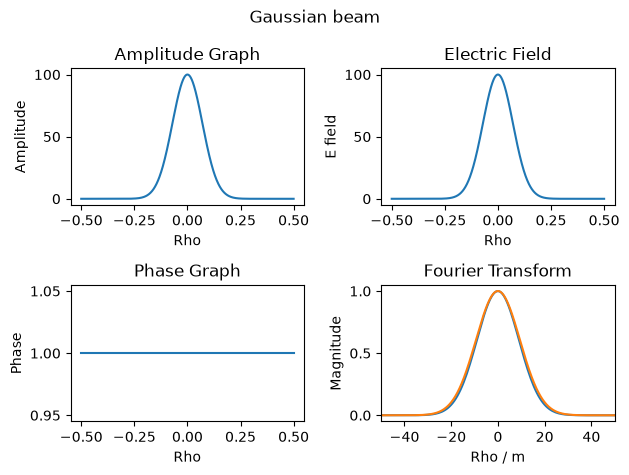

In [5]:
wavelength = 523
omega_0 = 0.1
z = 0.00000000000001
a_0 = 100
n = 1
window = omega_0 * 5
rho_values = np.linspace(-window,window,1000)
amp, phase = gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_values, n)

fig, ax = plt.subplots(2,2)

ax[0,0].plot(rho_values, amp, '-')
ax[0,0].set_xlabel('Rho')
ax[0,0].set_ylabel('Amplitude')
ax[0,0].set_title('Amplitude Graph')

ax[1,0].plot(rho_values, phase, '-')
ax[1,0].set_xlabel('Rho')
ax[1,0].set_ylabel('Phase')
ax[1,0].set_title('Phase Graph')

ax[0,1].plot(rho_values, phase*amp, '-')
ax[0,1].set_xlabel('Rho')
ax[0,1].set_ylabel('E field')
ax[0,1].set_title('Electric Field')

rho_values = np.linspace(-3,3,1000)
amp, phase = gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_values, n)

def fourier_transform(x,y):
    """
    Does a fourier transform on a graph to find the constituent frequencies
    Args:
        x (np.array): linearly spaces x values
        y (np.array): the array of amplitude
    Returns:
        fft_freq (np.array): the frequencies found
        mag (np.array): the intensities of frequencies
    """
    fft_val = np.fft.fftshift(np.fft.fft(y))
    fft_freq = np.fft.fftshift(np.fft.fftfreq(len(x), 1/(len(x))))
    mag = np.abs(fft_val)
    return fft_freq, mag

z1 = 8000000
x, y = fourier_transform(rho_values, amp*phase)
x = x*wavelength*1e-9*z1/(2*np.pi)
y = y/np.max(y)
ax[1,1].plot(x,y)
ax[1,1].set_xlim(-50,50)
ax[1,1].set_title('Fourier Transform')
ax[1,1].set_ylabel('Magnitude')
ax[1,1].set_xlabel('Rho / m')

fig.suptitle('Gaussian beam')
plt.tight_layout()

rho_values = np.linspace(-50,50,1000)
amp, phase = gaussian_beam_rho(omega_0, z1, wavelength, a_0, rho_values, n)
plt.plot(rho_values, amp/np.max(amp))

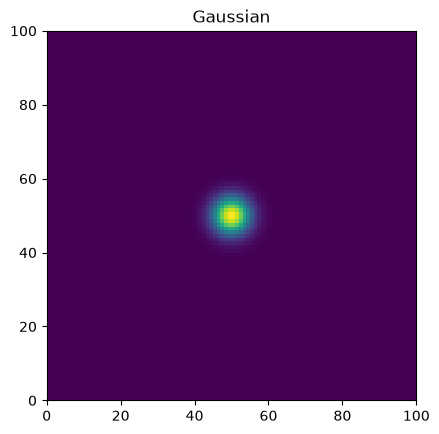

────────────────────────────────────────────────────────────


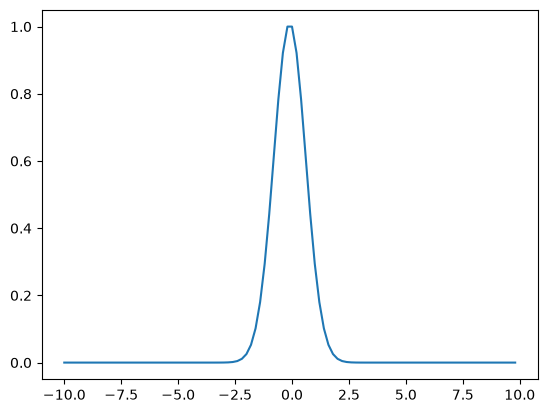

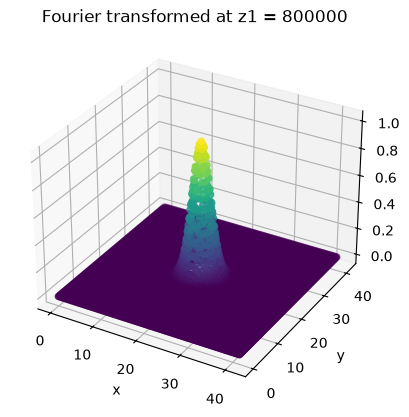

────────────────────────────────────────────────────────────


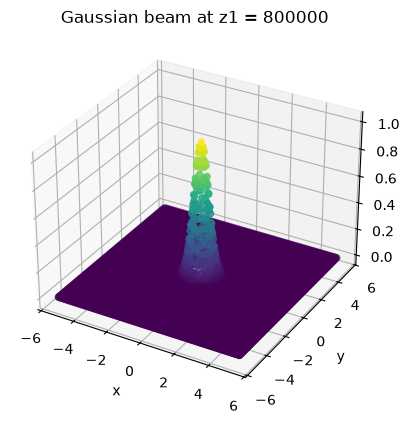

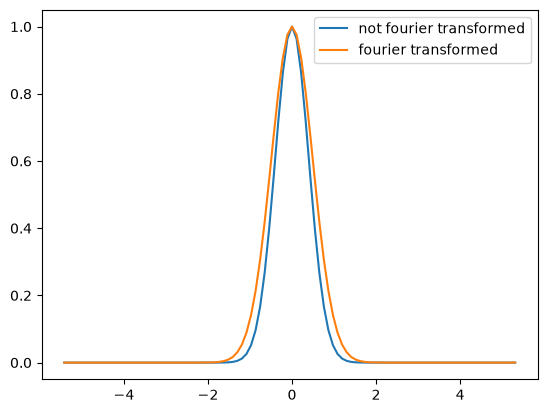

In [12]:
def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float or np.array): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (math.e**((-(rho(x, y))**2)/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z
                                      + ((wavenumber(n, wavelength) * (rho(x, y)) ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength)))
                                      - zeta_function(omega_0, z, wavelength)))
    return amplitude, phase

#--------------------------------------------------------------------------------------------------

# sets initial parameters of the beam

wavelength = 523
omega_0 = 0.5
z = 0.00000000000001 # at the source
a_0 = 100
n = 1
increasing = omega_0 * 100
variable = omega_0 * 10
# defines a meshgrid of xy values and calculates the beam at this point
x_values = np.linspace(-variable,variable,100)
y_values = np.linspace(-variable,variable,100)
x_values, y_values = np.meshgrid(x_values, y_values)
amp, phase = gaussian_beam(omega_0, z, wavelength, a_0, x_values, y_values, n)

# plots this as an image in 2D to be observed
plt.figure()
plt.imshow(amp, extent = [0,len(amp), 0, len(amp[0])], origin = 'lower')
plt.title('Gaussian')
plt.show()
print('─' * 60)
    
marginal = np.sum(amp, 0)
plt.plot(np.linspace(-10,10,100, endpoint = False), marginal/np.max(marginal), '-', label = (f'Sampling over window = {int(2*variable)}'))


#--------------------------------------------------------------------------------------------------

def calculate_2dft(input):
    """
    Calculates the 2D Fast Fourier Transform of an image
    Args:
        input (nested np.array): the nested array of values that come out of the gaussian_beam function
    Returns:
        np.fft.ifftshift(ft) (nested np.array): the fourier transformed arrays
    """
    ft = np.fft.ifftshift(input) # shifts the input
    ft = np.fft.fft2(ft) # performs 2D fft
    return np.fft.fftshift(ft) # inverse shifts

# does the 2D fourier transform and normalises the values
ft = calculate_2dft(amp*phase)
ft_norm = abs(ft)/np.max(abs(ft))

z1=800000 # defining a length far beyond the Fraunhofer condition for the parameters set

# defines a new meshgrid of xy coordinates to enable plotting in 3D, including the corrections needed for Fraunhofer diffraction

x = np.linspace(0,len(ft_norm), len(ft_norm), endpoint = False)
x = x*wavelength*1e-9*z1
y = np.linspace(0,len(ft_norm[0]), len(ft_norm[0]), endpoint = False)
y = y*wavelength*1e-9*z1
x, y = np.meshgrid(x,y)

#plots the fft of the source ideal beam
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, abs(ft_norm), c=ft_norm, marker='o', s=20)
plt.title(f'Fourier transformed at z1 = {z1}')
plt.xlabel('x')
plt.ylabel('y')

plt.show()
print('─' * 60) # separation line

ft_norm1 = ft_norm + 1
ft_norm1 -= 1

#--------------------------------------------------------------------------------------------------

# linear space value that works for this p
scaling_number = 10020/(1 + ((omega_0 - 0.001673)/(-0.002557))**2) + 3741/(1 + ((omega_0 + 0.005825)/0.003073)**2) + 0.682

a = variable * scaling_number

# defines a new meshgrid and calculates the beam at this point
x_values = np.linspace(-a, a,100, endpoint = False)
y_values = np.linspace(-a, a,100, endpoint = False)
x_values, y_values = np.meshgrid(x_values, y_values)
amp, phase = gaussian_beam(omega_0, z1, wavelength, a_0, x_values, y_values, n)

# plots the graph of the beam at z1
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_values, y_values, abs(amp/np.max(amp)), c=amp, marker='o', s=20)
plt.title(f'Gaussian beam at z1 = {z1}')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

#--------------------------------------------------------------------------------

marginal = np.sum(amp, 0)
plt.plot(np.linspace(-a,a,100, endpoint = False), marginal/np.max(marginal), '-', label = 'not fourier transformed')

marginal1 = np.sum(ft_norm1, 0)

plt.plot(np.linspace(-a,a, 100, endpoint = False),marginal1/np.max(marginal1), '-', label = 'fourier transformed')

plt.legend()
plt.show()

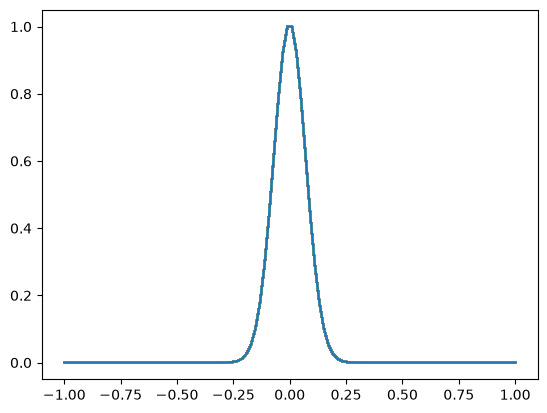

In [205]:
wavelength = 523
omega_0 = 0.1
z = 0.00000000000001 # at the source
a_0 = 100
n = 1
variable = omega_0 
# defines a meshgrid of xy values and calculates the beam at this point
x_values = np.linspace(-variable,variable,100)
y_values = np.linspace(-variable,variable,100)
x_values, y_values = np.meshgrid(x_values, y_values)
amp, phase = gaussian_beam(omega_0, z, wavelength, a_0, x_values, y_values, n)
slice_2d = amp[len(y_values)//2, :]

plt.plot(y_values, slice_2d/np.max(slice_2d), '-')

y_values = np.linspace(-variable,variable,100)
amp, phase = gaussian_beam(omega_0, z, wavelength, a_0, 0, y_values, n)
plt.plot(y_values, amp/np.max(amp))


# this shows that it is not due to the gaussian_beam function not coping with a meshgrid. Varying the value of omega_0 does not cause deviations, once the window of viewing is set to be consistent

possible error sources: 

 - post-fft scaling (most likely)
 - under/over sampling post-fft (possible)
 - me being stupid (certainly)
 - gaussian beam function (unlikely)